In [1]:
%load_ext cuml.accel
%run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
# %run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset, Subset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap
from joblib import Parallel, delayed
from tqdm import tqdm

/opt/py_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
workspace = "/workspace/alvin/SAR_ML"
# workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

Found 1345 .mat files


Fitting GMMs:   0%|          | 0/1345 [00:00<?, ?it/s]

Fitting GMMs: 100%|██████████| 1345/1345 [01:02<00:00, 21.39it/s]


In [5]:
# preload once outside
preloaded = {}
clutter_files = [
    os.path.join(clutter_dir, f)
    for f in os.listdir(clutter_dir)
    if os.path.isfile(os.path.join(clutter_dir, f))
]
for f in tqdm(clutter_files, desc="Preloading"):
    C_complex = read_mstar_clutter_complex(f)
    C_raw = Magnitude()(C_complex)
    preloaded[f] = LogMapping(c=1000.0)(C_raw)

Preloading:   0%|          | 0/100 [00:00<?, ?it/s]

Preloading: 100%|██████████| 100/100 [00:15<00:00,  6.31it/s]


In [6]:
clutter_cache_lst = Parallel(n_jobs=-1)(
    delayed(build_clutter_cache)(meas_ds, clutter_dir, preloaded = preloaded)
    for i in range(100)
)

Building clutter cache: 100%|██████████| 1345/1345 [01:16<00:00, 17.59it/s]


In [6]:
import pickle

# Save
# with open(os.path.join(workspace, "weights/SSR/Experiment_2/100_clutter_cache.pkl"), "wb") as f:
#     pickle.dump(clutter_cache_lst, f)
    
# Load
with open(os.path.join(workspace, "weights/SSR/Experiment_2/100_clutter_cache.pkl"), "rb") as f:
    clutter_cache_lst = pickle.load(f)

In [7]:
big_meas_ds = ConcatDataset([
    DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/real"),
        extensions=(".mat"),
        transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache_lst[i], preloaded = preloaded), NumpyToTensor3Channel()]),
        loader = mat_file_loader
    ) for i in range(100)]
                           )

In [8]:
train_ds = big_meas_ds
test_ds = synth_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [ ]:
seed_lst = [42]

train_loss = []
# val_loss = []
train_acc =[]
# val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=16, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=16, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(meas_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        # "val_loss" : [],
        "train_acc": [],
        # "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in tqdm(dataloaders[phase], leave = False):
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch % 15 == 0:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "loss": epoch_loss,
                "history": history,
            }, os.path.join(workspace, f"weights/SSR/Experiment_2/seed{seed}_epoch{epoch}.pth"))
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Experiment_2/rn18_seed{seed}_b16.pth"))

train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 42
Epoch 0
First layer mean: -0.000035


train Loss: 0.0550409 Acc: 0.9819182
Epoch 0 LR: 0.0002999815
Epoch 1


train Loss: 0.0063938 Acc: 0.9981115
Epoch 1 LR: 0.0002999261
Epoch 2


train Loss: 0.0057124 Acc: 0.9982602
Epoch 2 LR: 0.0002998336
Epoch 3


train Loss: 0.0037463 Acc: 0.9989517
Epoch 3 LR: 0.0002997043
Epoch 4


...

train Loss: 0.0000000 Acc: 1.0000000
Epoch 164 LR: 0.0000223819
Epoch 165


train Loss: 0.0000000 Acc: 1.0000000
Epoch 165 LR: 0.0000211678
Epoch 166


train Loss: 0.0000000 Acc: 1.0000000
Epoch 166 LR: 0.0000199856
Epoch 167


train Loss: 0.0000000 Acc: 1.0000000
Epoch 167 LR: 0.0000188354
Epoch 168


 83%|████████▎ | 1750/2102 [00:36<00:06, 55.42it/s]

In [14]:
seed = 42

train_loss = []
train_acc = []

set_seed(seed)

dataloaders = {
    "train": DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=16, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
    # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
    "test": DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=16, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
}

# Setup model, optimizer, scheduler, dataloaders as usual...
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, len(meas_ds.class_to_idx))
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load checkpoint
checkpoint = torch.load(os.path.join(workspace, f"weights/SSR/Experiment_2/seed{seed}_epoch165.pth"))
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
history = checkpoint["history"]
start_epoch = checkpoint["epoch"] + 1
print(f"Resuming from epoch {start_epoch}")

# Training loops
num_epochs = 200
for epoch in range(start_epoch, num_epochs):
    if epoch == start_epoch:
        print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
    for phase in ["train"]:
        if phase == "train":
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0 # correct predictions

        for inputs, labels in tqdm(dataloaders[phase], leave = False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # clear the gradient from previous iteration

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels) # check if output and labels match

                if phase == "train":
                    loss.backward()
                    optimizer.step()
                    # scheduler.step() # scheduler here if OneCycleLR

            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects / dataset_sizes[phase]
        
        history[f"{phase}_loss"].append(epoch_loss)
        history[f"{phase}_acc"].append(epoch_acc)

        print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")

    scheduler.step()
    print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    if epoch % 15 == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "loss": epoch_loss,
            "history": history,
        }, os.path.join(workspace, f"weights/SSR/Experiment_2/seed{seed}_epoch{epoch}.pth"))
    
print("Training complete!")

train_loss.append(history["train_loss"])
# val_loss.append(history["val_loss"])
train_acc.append(history["train_acc"])
# val_acc.append(history["val_acc"])

torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Experiment_2/rn18_seed{seed}_b16.pth"))

train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Resuming from epoch 166
First layer mean: -0.000255


train Loss: 0.0000000 Acc: 1.0000000
Epoch 166 LR: 0.0000199856


train Loss: 0.0000000 Acc: 1.0000000
Epoch 167 LR: 0.0000188354


train Loss: 0.0000000 Acc: 1.0000000
Epoch 168 LR: 0.0000177177


train Loss: 0.0000000 Acc: 1.0000000
Epoch 169 LR: 0.0000166327


...

train Loss: 0.0000000 Acc: 1.0000000
Epoch 195 LR: 0.0000005957


train Loss: 0.0000000 Acc: 1.0000000
Epoch 196 LR: 0.0000004664


train Loss: 0.0000000 Acc: 1.0000000
Epoch 197 LR: 0.0000003739


train Loss: 0.0000000 Acc: 1.0000000
Epoch 198 LR: 0.0000003185


train Loss: 0.0000000 Acc: 1.0000000
Epoch 199 LR: 0.0000003000
Training complete!


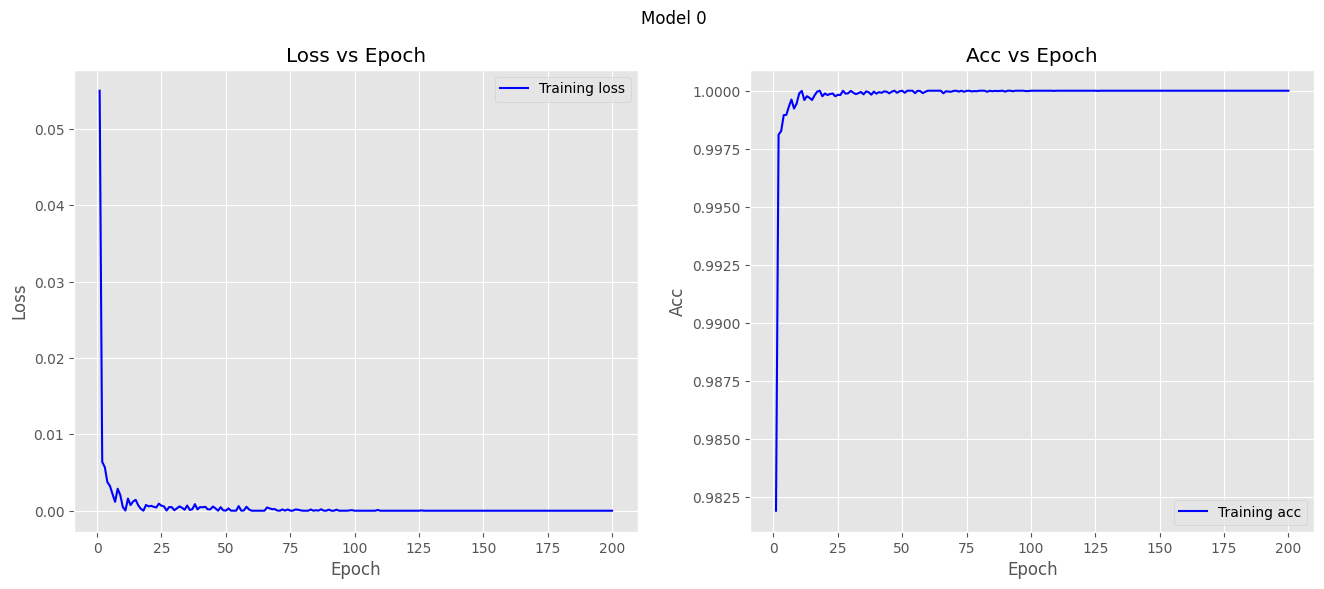

In [15]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        # ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        # ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}")
        plt.show()

In [17]:
seed_lst = [42]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_2/rn18_seed42_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 42
Test Accuracy: 0.8520


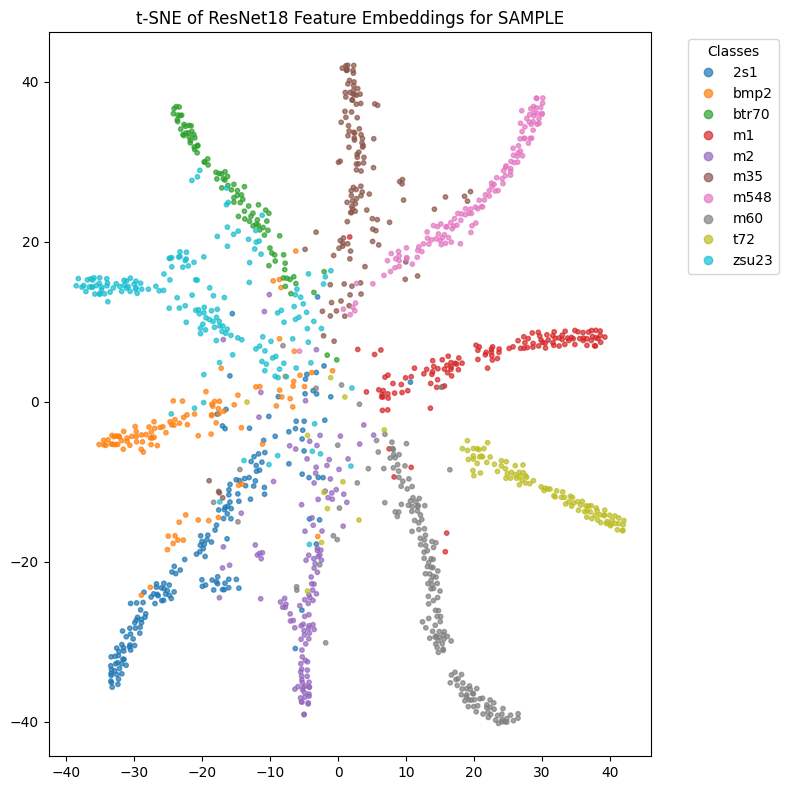

In [18]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_2/rn18_seed42_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(meas_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

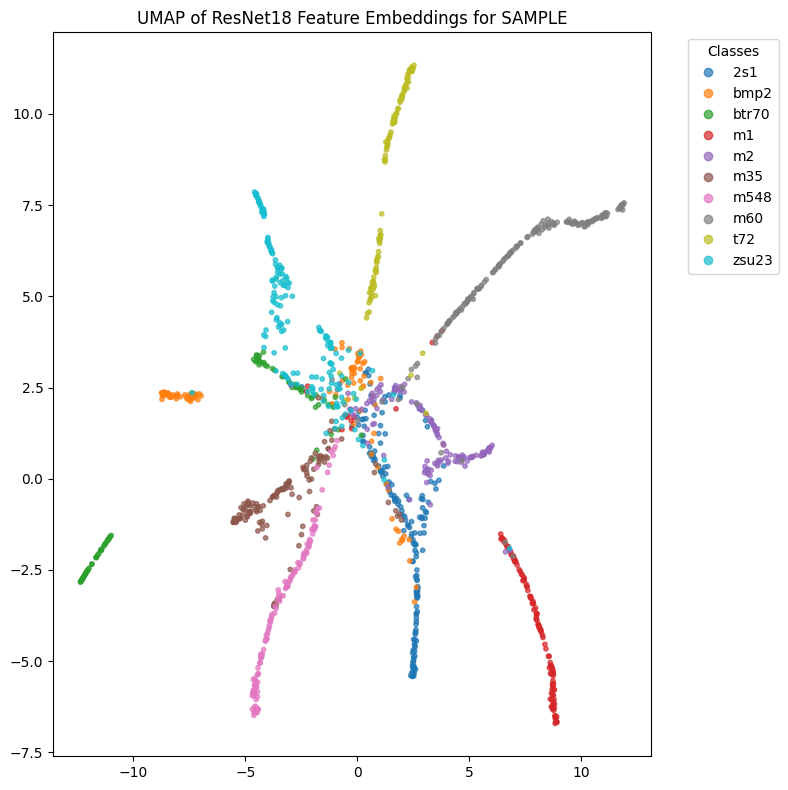

In [19]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_2/rn18_seed42_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(meas_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()